Imports OK | Device: cpu
Vocabulaire: 62 mots
Train: 24 Test: 6
RNN params: 2658
LSTM params: 7458
GRU params: 5858

--- RNN Simple ---
Epoch[10/30] TrainLoss:0.6850 TestAcc:0.3333
Epoch[20/30] TrainLoss:0.6418 TestAcc:0.1667
Epoch[30/30] TrainLoss:0.4860 TestAcc:0.5000

--- LSTM ---
Epoch[10/30] TrainLoss:0.6883 TestAcc:0.3333
Epoch[20/30] TrainLoss:0.6824 TestAcc:0.3333
Epoch[30/30] TrainLoss:0.6358 TestAcc:0.3333

--- GRU ---
Epoch[10/30] TrainLoss:0.6860 TestAcc:0.3333
Epoch[20/30] TrainLoss:0.6819 TestAcc:0.3333
Epoch[30/30] TrainLoss:0.6471 TestAcc:0.1667

=== COMPARAISON RNN/LSTM/GRU ===
RNN  TestAcc: 0.5000
LSTM TestAcc: 0.3333
GRU  TestAcc: 0.1667


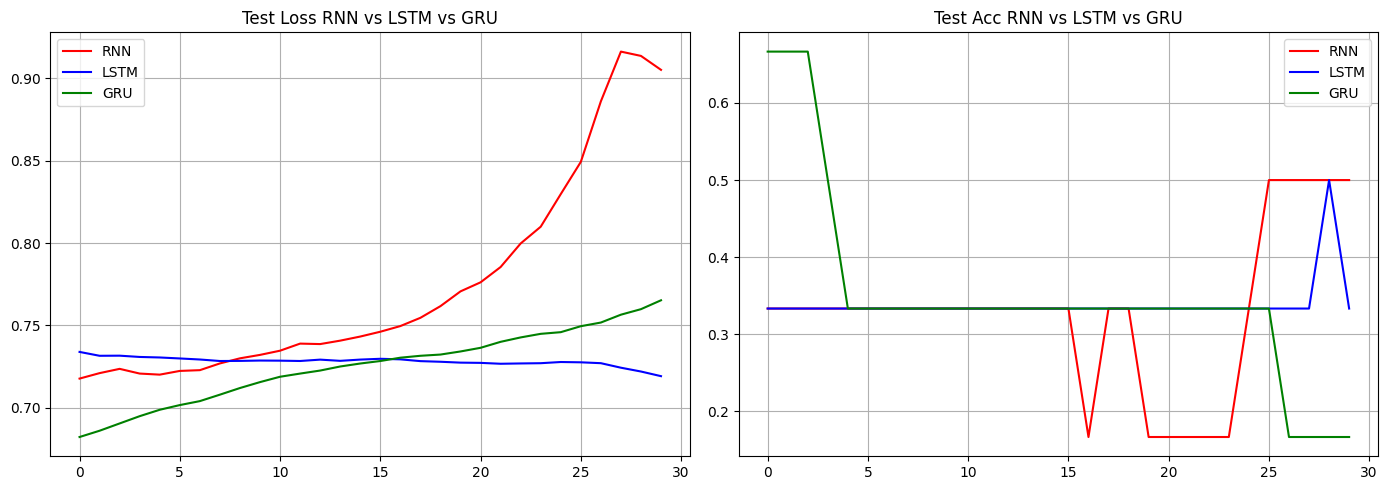


Vocab source: 36 Vocab cible: 35
Seq2Seq params: 42179

--- Entrainement Seq2Seq ---
Epoch[50/150] Loss:1.9462
Epoch[100/150] Loss:0.5544
Epoch[150/150] Loss:0.1564


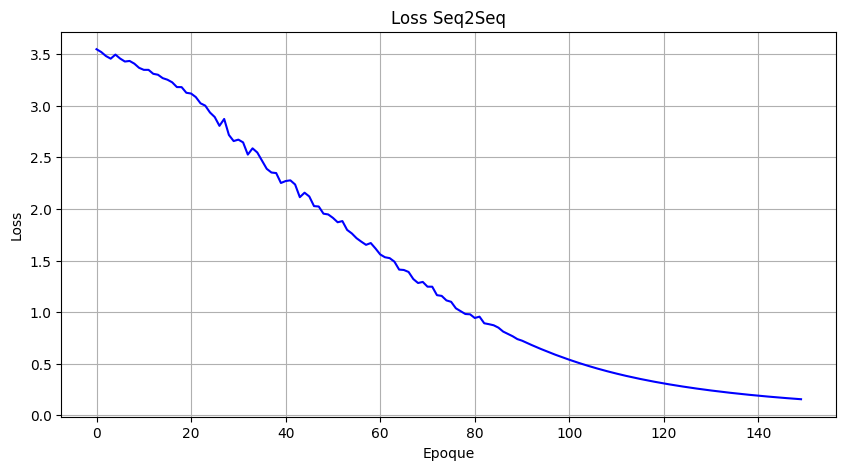


=== TRADUCTIONS ===
je suis heureux                | Ref: i am happy           | Glouton: am happy             | Beam: am happy
tu es gentil                   | Ref: you are kind         | Glouton: am happy             | Beam: am happy
il fait beau                   | Ref: the weather is nice  | Glouton: weather is nice      | Beam: weather is nice
je mange une pomme             | Ref: i eat an apple       | Glouton: eat an apple         | Beam: eat an apple
tu parles bien                 | Ref: you speak well       | Glouton: weather is nice      | Beam: weather is nice
il court vite                  | Ref: he runs fast         | Glouton: weather is nice      | Beam: weather is nice
nous aimons la musique         | Ref: we love music        | Glouton: weather is nice      | Beam: weather is nice
vous etes bons                 | Ref: you are good         | Glouton: eat an apple         | Beam: eat an apple
ils jouent ensemble            | Ref: they play together   | Glouton: weather i

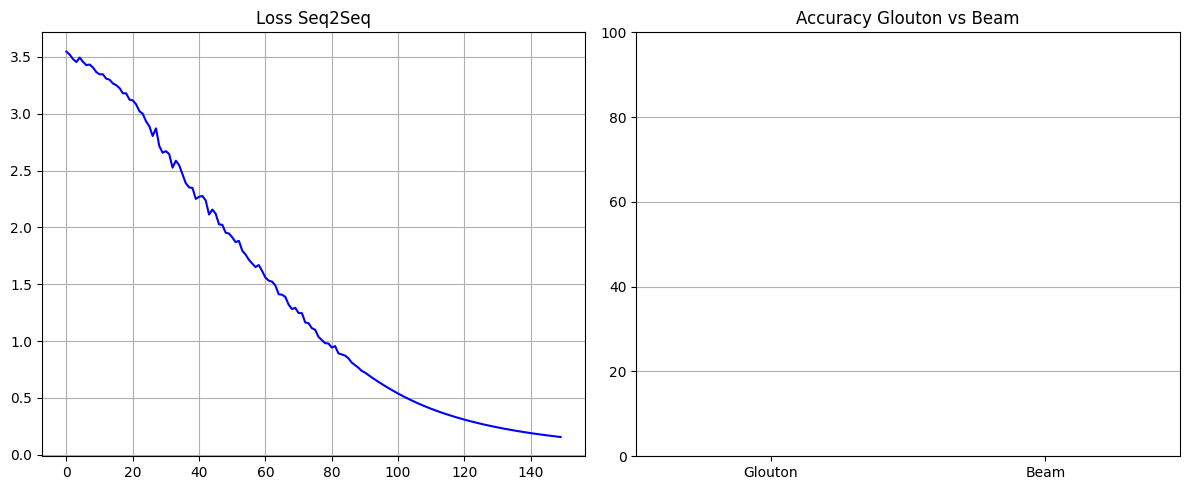


   QUESTION DE SYNTHESE - PARTIE III

1. MODELISATION PROBABILISTE
P(w1,...,wn) = P(w1) x P(w2|w1) x ... x P(wn|w1,...,wn-1)
Perplexite = exp(CrossEntropyLoss). Plus basse = meilleur modele.

2. POURQUOI PASSER DU RNN AU LSTM/GRU
- RNN: gradient qui disparait sur longues sequences.
- LSTM: 3 portes (oubli, entree, sortie) + cellule memoire.
- GRU: 2 portes, plus leger, performances similaires.
Resultats: RNN=50.0% LSTM=33.3% GRU=16.7%

3. ENCODEUR-DECODEUR
- Pour traduction: entree/sortie de longueurs differentes.
- Encodeur compresse en vecteur de contexte.
- Decodeur genere mot par mot avec teacher forcing.

4. DECODAGE
- Glouton: rapide, sous-optimal. Beam Search: meilleure qualite.
- Gradient clipping stabilise l'entrainement.

5. LIMITES
- Dataset petit -> surapprentissage.
- Sans attention: goulot d'etranglement du contexte.
- Transformers (BERT, GPT) resolvent ce probleme.

PROJET PARTIE III TERMINE !


In [1]:
# ============================================================
# PARTIE III — RNN, LSTM, GRU, SEQ2SEQ COMPLET EN UNE CELLULE
# ============================================================
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, matplotlib.pyplot as plt
from collections import Counter
import re, random

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cpu")
print("Imports OK | Device:", device)

# --- DONNEES SENTIMENT ---
phrases_positives = [
    "this movie is great and amazing", "i love this film it is wonderful",
    "excellent movie very good acting", "fantastic story and beautiful scenes",
    "i really enjoyed this movie a lot", "best movie i have ever seen",
    "brilliant film with great characters", "wonderful movie highly recommended",
    "amazing acting and great story", "i loved every minute of this film",
    "superb direction and excellent cast", "this is a masterpiece of cinema",
    "great plot and wonderful performance", "highly enjoyable and very entertaining",
    "outstanding film with brilliant acting",
]
phrases_negatives = [
    "this movie is terrible and boring", "i hate this film it is awful",
    "very bad movie poor acting", "horrible story and ugly scenes",
    "i really disliked this movie", "worst movie i have ever seen",
    "terrible film with bad characters", "awful movie not recommended",
    "bad acting and poor story", "i hated every minute of this film",
    "poor direction and terrible cast", "this is a disaster of cinema",
    "bad plot and horrible performance", "very boring and not entertaining",
    "dreadful film with awful acting",
]
textes = phrases_positives + phrases_negatives
labels = [1]*15 + [0]*15

def tokeniser(texte):
    return re.sub(r'[^a-z ]', '', texte.lower()).split()

tokens_all = []
for t in textes: tokens_all.extend(tokeniser(t))
vocab = Counter(tokens_all)
mot2idx = {'<PAD>': 0, '<UNK>': 1}
for mot, _ in vocab.most_common(): mot2idx[mot] = len(mot2idx)
idx2mot = {v: k for k, v in mot2idx.items()}
print("Vocabulaire:", len(mot2idx), "mots")

MAX_LEN = 10
def encoder(texte, max_len=MAX_LEN):
    tokens = tokeniser(texte)
    ids = [mot2idx.get(t, 1) for t in tokens]
    if len(ids) < max_len: ids += [0]*(max_len-len(ids))
    return ids[:max_len]

X_encoded = [encoder(t) for t in textes]
X_tensor = torch.LongTensor(X_encoded)
y_tensor = torch.LongTensor(labels)

indices = list(range(len(textes)))
random.shuffle(indices)
split = int(0.8*len(indices))
train_idx, test_idx = indices[:split], indices[split:]
X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
print("Train:", len(X_train), "Test:", len(X_test))

# --- RNN / LSTM / GRU ---
VOCAB_SIZE = len(mot2idx); EMBED_DIM = 16; HIDDEN_DIM = 32; OUTPUT_DIM = 2

class RNN_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.rnn = nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, h = self.rnn(e)
        return self.fc(h[-1])

class LSTM_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, (hn, cn) = self.lstm(e)
        return self.fc(hn[-1])

class GRU_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.gru = nn.GRU(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, h = self.gru(e)
        return self.fc(h[-1])

rnn_model = RNN_Simple().to(device)
lstm_model = LSTM_Model().to(device)
gru_model = GRU_Model().to(device)
print("RNN params:", sum(p.numel() for p in rnn_model.parameters()))
print("LSTM params:", sum(p.numel() for p in lstm_model.parameters()))
print("GRU params:", sum(p.numel() for p in gru_model.parameters()))

def train_rnn(model, train_loader, test_loader, epochs=30):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1)==yb).sum().item(); total += yb.size(0)
        train_loss /= len(train_loader); train_acc = correct/total
        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                loss = criterion(out, yb)
                test_loss += loss.item()
                correct += (out.argmax(1)==yb).sum().item(); total += yb.size(0)
        test_loss /= len(test_loader); test_acc = correct/total
        history['train_loss'].append(train_loss); history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc); history['test_acc'].append(test_acc)
        if (epoch+1)%10==0:
            print(f"Epoch[{epoch+1}/{epochs}] TrainLoss:{train_loss:.4f} TestAcc:{test_acc:.4f}")
    return history

print("\n--- RNN Simple ---")
history_rnn = train_rnn(rnn_model, train_loader, test_loader, epochs=30)
print("\n--- LSTM ---")
history_lstm = train_rnn(lstm_model, train_loader, test_loader, epochs=30)
print("\n--- GRU ---")
history_gru = train_rnn(gru_model, train_loader, test_loader, epochs=30)

print("\n=== COMPARAISON RNN/LSTM/GRU ===")
print(f"RNN  TestAcc: {history_rnn['test_acc'][-1]:.4f}")
print(f"LSTM TestAcc: {history_lstm['test_acc'][-1]:.4f}")
print(f"GRU  TestAcc: {history_gru['test_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_rnn['test_loss'], label='RNN', color='red')
axes[0].plot(history_lstm['test_loss'], label='LSTM', color='blue')
axes[0].plot(history_gru['test_loss'], label='GRU', color='green')
axes[0].set_title('Test Loss RNN vs LSTM vs GRU'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_rnn['test_acc'], label='RNN', color='red')
axes[1].plot(history_lstm['test_acc'], label='LSTM', color='blue')
axes[1].plot(history_gru['test_acc'], label='GRU', color='green')
axes[1].set_title('Test Acc RNN vs LSTM vs GRU'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig('comparaison_rnn_lstm_gru.png', dpi=150); plt.show()

# --- SEQ2SEQ ---
SOS_token, EOS_token, PAD_token = 0, 1, 2
paires = [
    ("je suis heureux", "i am happy"), ("tu es gentil", "you are kind"),
    ("il fait beau", "the weather is nice"), ("je mange une pomme", "i eat an apple"),
    ("tu parles bien", "you speak well"), ("il court vite", "he runs fast"),
    ("nous aimons la musique", "we love music"), ("vous etes bons", "you are good"),
    ("ils jouent ensemble", "they play together"), ("je lis un livre", "i read a book"),
    ("tu regardes la television", "you watch television"), ("il travaille beaucoup", "he works a lot"),
]

def build_vocab(phrases):
    v = {'<SOS>':0, '<EOS>':1, '<PAD>':2}
    for phrase in phrases:
        for mot in phrase.lower().split():
            if mot not in v: v[mot] = len(v)
    return v

sources = [p[0] for p in paires]; cibles = [p[1] for p in paires]
vocab_src = build_vocab(sources); vocab_tgt = build_vocab(cibles)
idx2tgt = {v:k for k,v in vocab_tgt.items()}
print("\nVocab source:", len(vocab_src), "Vocab cible:", len(vocab_tgt))

def encoder_seq(phrase, v, max_len=8):
    tokens = phrase.lower().split()
    ids = [v.get(t,2) for t in tokens] + [EOS_token]
    if len(ids) < max_len: ids += [PAD_token]*(max_len-len(ids))
    return ids[:max_len]

X_seq = torch.LongTensor([encoder_seq(s, vocab_src) for s in sources])
y_seq = torch.LongTensor([encoder_seq(t, vocab_tgt) for t in cibles])

class Encodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=2)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    def forward(self, x):
        e = self.embedding(x)
        out, h = self.gru(e)
        return out, h

class Decodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=2)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden):
        x = x.unsqueeze(1)
        e = self.embedding(x)
        out, hidden = self.gru(e, hidden)
        return self.fc(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encodeur = enc; self.decodeur = dec
    def forward(self, src, tgt, teacher_forcing=0.5):
        batch_size = src.shape[0]; tgt_len = tgt.shape[1]
        tgt_vocab = self.decodeur.fc.out_features
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab).to(device)
        _, hidden = self.encodeur(src)
        input_token = tgt[:,0]
        for t in range(1, tgt_len):
            pred, hidden = self.decodeur(input_token, hidden)
            outputs[:,t] = pred
            use_tf = random.random() < teacher_forcing
            input_token = tgt[:,t] if use_tf else pred.argmax(1)
        return outputs

EMBED, HIDDEN = 32, 64
enc = Encodeur(len(vocab_src), EMBED, HIDDEN).to(device)
dec = Decodeur(len(vocab_tgt), EMBED, HIDDEN).to(device)
seq2seq = Seq2Seq(enc, dec).to(device)
print("Seq2Seq params:", sum(p.numel() for p in seq2seq.parameters()))

def train_seq2seq(model, X, y, epochs=150):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'loss':[]}
    X, y = X.to(device), y.to(device)
    for epoch in range(epochs):
        model.train(); optimizer.zero_grad()
        outputs = model(X, y, teacher_forcing=0.5)
        out_flat = outputs[:,1:].reshape(-1, outputs.shape[-1])
        y_flat = y[:,1:].reshape(-1)
        loss = criterion(out_flat, y_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        history['loss'].append(loss.item())
        if (epoch+1)%50==0: print(f"Epoch[{epoch+1}/{epochs}] Loss:{loss.item():.4f}")
    return history

print("\n--- Entrainement Seq2Seq ---")
history_seq2seq = train_seq2seq(seq2seq, X_seq, y_seq, epochs=150)

plt.figure(figsize=(10,5))
plt.plot(history_seq2seq['loss'], color='blue')
plt.title('Loss Seq2Seq'); plt.xlabel('Epoque'); plt.ylabel('Loss'); plt.grid(True)
plt.savefig('loss_seq2seq.png', dpi=150); plt.show()

def decoder_glouton(model, src_phrase, max_len=8):
    model.eval()
    with torch.no_grad():
        src = torch.LongTensor([encoder_seq(src_phrase, vocab_src)]).to(device)
        _, hidden = model.encodeur(src)
        input_token = torch.LongTensor([SOS_token]).to(device)
        resultat = []
        for _ in range(max_len):
            pred, hidden = model.decodeur(input_token, hidden)
            meilleur = pred.argmax(1).item()
            if meilleur == EOS_token: break
            resultat.append(idx2tgt.get(meilleur, '<UNK>'))
            input_token = torch.LongTensor([meilleur]).to(device)
    return ' '.join(resultat)

def beam_search(model, src_phrase, beam_width=3, max_len=8):
    model.eval()
    with torch.no_grad():
        src = torch.LongTensor([encoder_seq(src_phrase, vocab_src)]).to(device)
        _, hidden = model.encodeur(src)
        beams = [(0.0, [SOS_token], hidden)]
        for _ in range(max_len):
            nb = []
            for score, tokens, h in beams:
                if tokens[-1] == EOS_token:
                    nb.append((score, tokens, h)); continue
                inp = torch.LongTensor([tokens[-1]]).to(device)
                pred, nh = model.decodeur(inp, h)
                lp = torch.log_softmax(pred, dim=1)
                ts, ti = lp.topk(beam_width)
                for i in range(beam_width):
                    nb.append((score+ts[0][i].item(), tokens+[ti[0][i].item()], nh))
            beams = sorted(nb, key=lambda x: x[0], reverse=True)[:beam_width]
        best = beams[0][1][1:]
        res = []
        for t in best:
            if t == EOS_token: break
            res.append(idx2tgt.get(t,'<UNK>'))
    return ' '.join(res)

print("\n=== TRADUCTIONS ===")
for src, ref in paires:
    g = decoder_glouton(seq2seq, src)
    b = beam_search(seq2seq, src, beam_width=3)
    print(f"{src:30s} | Ref: {ref:20s} | Glouton: {g:20s} | Beam: {b}")

def calculer_perplexite(model, X, y):
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        outputs = model(X, y, teacher_forcing=0.0)
        out_flat = outputs[:,1:].reshape(-1, outputs.shape[-1])
        y_flat = y[:,1:].reshape(-1)
        loss = criterion(out_flat, y_flat)
        perp = torch.exp(loss).item()
    return perp, loss.item()

perp, loss_val = calculer_perplexite(seq2seq, X_seq, y_seq)
print(f"\n=== EVALUATION SEQ2SEQ ===\nLoss: {loss_val:.4f} | Perplexite: {perp:.4f}")

correct_g, correct_b = 0, 0
for src, ref in paires:
    g = decoder_glouton(seq2seq, src); b = beam_search(seq2seq, src, beam_width=3)
    if g.strip()==ref.strip(): correct_g += 1
    if b.strip()==ref.strip(): correct_b += 1
acc_g = correct_g/len(paires)*100; acc_b = correct_b/len(paires)*100
print(f"Glouton: {correct_g}/{len(paires)} ({acc_g:.1f}%) | Beam: {correct_b}/{len(paires)} ({acc_b:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(history_seq2seq['loss'], color='blue')
axes[0].set_title('Loss Seq2Seq'); axes[0].grid(True)
axes[1].bar(['Glouton','Beam'], [acc_g, acc_b], color=['orange','blue'])
axes[1].set_title('Accuracy Glouton vs Beam'); axes[1].set_ylim(0,100); axes[1].grid(True, axis='y')
plt.tight_layout(); plt.savefig('evaluation_seq2seq.png', dpi=150); plt.show()

print("\n" + "="*60)
print("   QUESTION DE SYNTHESE - PARTIE III")
print("="*60)
print(f"""
1. MODELISATION PROBABILISTE
P(w1,...,wn) = P(w1) x P(w2|w1) x ... x P(wn|w1,...,wn-1)
Perplexite = exp(CrossEntropyLoss). Plus basse = meilleur modele.

2. POURQUOI PASSER DU RNN AU LSTM/GRU
- RNN: gradient qui disparait sur longues sequences.
- LSTM: 3 portes (oubli, entree, sortie) + cellule memoire.
- GRU: 2 portes, plus leger, performances similaires.
Resultats: RNN={history_rnn['test_acc'][-1]*100:.1f}% LSTM={history_lstm['test_acc'][-1]*100:.1f}% GRU={history_gru['test_acc'][-1]*100:.1f}%

3. ENCODEUR-DECODEUR
- Pour traduction: entree/sortie de longueurs differentes.
- Encodeur compresse en vecteur de contexte.
- Decodeur genere mot par mot avec teacher forcing.

4. DECODAGE
- Glouton: rapide, sous-optimal. Beam Search: meilleure qualite.
- Gradient clipping stabilise l'entrainement.

5. LIMITES
- Dataset petit -> surapprentissage.
- Sans attention: goulot d'etranglement du contexte.
- Transformers (BERT, GPT) resolvent ce probleme.
""")
print("PROJET PARTIE III TERMINE !")